<a href="https://colab.research.google.com/github/celalthedon/traffic-vehicle-counting-yolo-tracking/blob/main/traffic_vehicle_counting_yolo_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics opencv-python kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00


In [2]:
import os
from pathlib import Path

In [8]:
!pip install -q kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 9.2 MB/s eta 0:00:00


In [15]:
import os

os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

print("Kaggle authenticated successfully!")

Kaggle authenticated successfully!


In [16]:
!kaggle datasets list -s vehicle

ref                                                      title                                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ---------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nehalbirla/vehicle-dataset-from-cardekho                 Vehicle dataset                              299060  2023-01-14 19:35:33.217000         223068       1213                1  
syedanwarafridi/vehicle-sales-data                       Vehicle Sales Data                         19753181  2024-02-21 20:16:17.790000          87227        777                1  
nelgiriyewithana/australian-vehicle-prices               Australian Vehicle Prices                    596123  2023-11-27 04:51:30.037000           8923        162                1  
marquis03/vehicle-classification                         Vehicle Classification           

In [17]:
!mkdir -p /content/datasets/ua_detrac

!kaggle datasets download \
  -d bratjay/ua-detrac-orig \
  -p /content/datasets/ua_detrac \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/bratjay/ua-detrac-orig
License(s): unknown
100% 9.23G/9.23G [02:06<00:00, 78.5MB/s]



In [18]:
from pathlib import Path

path = Path("/content/datasets/ua_detrac")

if path.exists():
    print("Path exists:", path)

    if path.is_dir():
        print("This is a folder. Contents:")
        for item in path.iterdir():
            print(item)

    elif path.is_file():
        print("This is a file:", path)

else:
    print("Path does not exist:", path)

Path exists: /content/datasets/ua_detrac
This is a folder. Contents:
/content/datasets/ua_detrac/DETRAC-Test-Annotations-XML
/content/datasets/ua_detrac/DETRAC-Train-Annotations-XML
/content/datasets/ua_detrac/DETRAC-Images
/content/datasets/ua_detrac/DETRAC-MOT-toolkit


In [22]:
from pathlib import Path

images_dir = Path("/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images")

for item in images_dir.iterdir():
    print(item)

/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40864
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40962
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40852
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_39031
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40201
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40212
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20012
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_39861
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20032
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40903
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40863
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_63554
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40992
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40855
/content/d

In [23]:
sample_seq = next(images_dir.iterdir())

print("Sample sequence:", sample_seq)

for item in list(sample_seq.iterdir())[:10]:
    print(item)

Sample sequence: /content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img00360.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01718.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img00500.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01667.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01453.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img00218.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01092.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01665.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img01428.jpg
/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_40162/img00919.jpg


In [24]:
images_dir = Path("/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images")
sample_seq = next(images_dir.iterdir())

In [25]:
from pathlib import Path

images_dir = Path("/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images")

sequence_dirs = sorted([p for p in images_dir.iterdir() if p.is_dir()])

print("Total sequences:", len(sequence_dirs))

for seq in sequence_dirs[:10]:
    print(seq.name)

Total sequences: 100
MVI_20011
MVI_20012
MVI_20032
MVI_20033
MVI_20034
MVI_20035
MVI_20051
MVI_20052
MVI_20061
MVI_20062


In [30]:
sequence_dirs[0]

PosixPath('/content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011')

In [31]:
sample_seq = sequence_dirs[0]

In [32]:
image_paths = sorted([
    p for p in sample_seq.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

In [36]:
print("total frames:", len(image_paths))
print("first frame:", image_paths[0])
print("last frame:", image_paths[-1])

total frames: 664
first frame: /content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011/img00001.jpg
last frame: /content/datasets/ua_detrac/DETRAC-Images/DETRAC-Images/MVI_20011/img00664.jpg


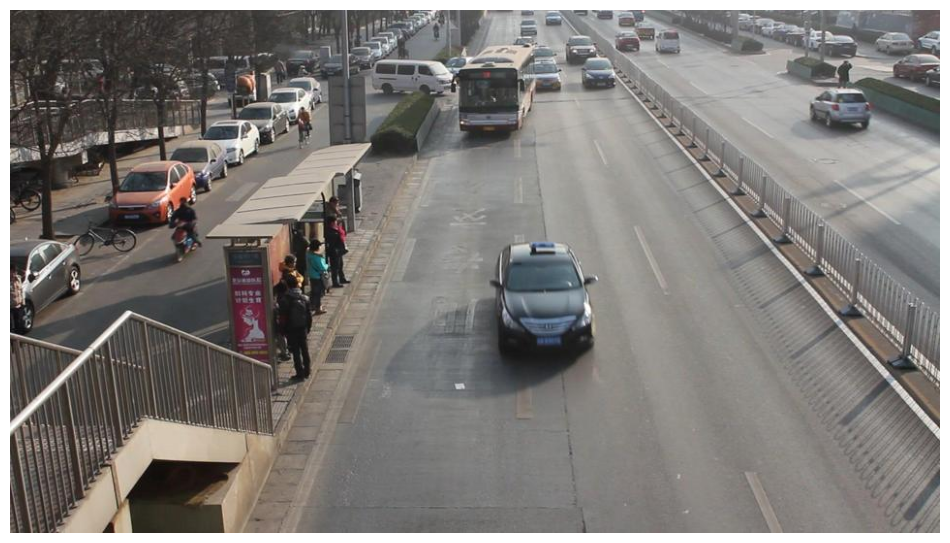

In [38]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(str(image_paths[-1]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [40]:
output_video_path = "/content/traffic_sample.mp4"

first_frame =cv2.imread(str(image_paths[0]))

In [41]:
first_frame.shape

(540, 960, 3)

In [42]:
first_frame.shape[:2]

(540, 960)

In [43]:
height, width = first_frame.shape[:2]

In [44]:
fps =  25

In [45]:
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

In [46]:
max_frames = min(1000, len(image_paths))

In [47]:
for img_path in image_paths[:max_frames]:
    frame = cv2.imread(str(img_path))
    if frame is None:
        continue
    writer.write(frame)

In [48]:
writer.release()

In [49]:
print("Saved video:", output_video_path)
print("Frames written:", max_frames)

Saved video: /content/traffic_sample.mp4
Frames written: 664


#YOLO TRACKING

In [51]:
!pip install -q ultralytics

In [85]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

In [87]:
custom_tracker_path = "/content/bytetrack_custom.yaml"

tracker_yaml = """
tracker_type: bytetrack

track_high_thresh: 0.25
track_low_thresh: 0.05
new_track_thresh: 0.25

track_buffer: 90
match_thresh: 0.85
fuse_score: True
"""

with open(custom_tracker_path, "w") as f:
    f.write(tracker_yaml)

print("Custom tracker saved:", custom_tracker_path)

Custom tracker saved: /content/bytetrack_custom.yaml


In [88]:
vehicle_names = {"car", "motorcycle", "bus", "truck"}

In [89]:
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [90]:
vehicle_class_ids = [
    class_id for class_id, class_name in model.names.items()
    if class_name in vehicle_names
]

In [91]:
print("Vehicle class IDs:", vehicle_class_ids)
print("Vehicle class names:", [model.names[i] for i in vehicle_class_ids])

Vehicle class IDs: [2, 3, 5, 7]
Vehicle class names: ['car', 'motorcycle', 'bus', 'truck']


In [92]:
results = model.track(
    source=output_video_path,
    tracker="/content/bytetrack_custom.yaml",
    conf=0.25,
    iou=0.5,
    classes=vehicle_class_ids,
    save=True,
    project="/content/runs",
    name="traffic_tracking_test"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/664) /content/traffic_sample.mp4: 384x640 17 cars, 1 motorcycle, 249.5ms
video 1/1 (frame 2/664) /content/traffic_sample.mp4: 384x640 16 cars, 1 motorcycle, 252.4ms
video 1/1 (frame 3/664) /content/traffic_sample.mp4: 384x640 16 cars, 256.0ms
video 1/1 (frame 4/664) /content/traffic_sample.mp4: 384x640 16 cars, 237.0ms
video 1/1 (frame 5/664) /content/traffic_sample.mp4: 384x640 17 cars, 237.9ms
video 1/1 (frame 6/664) /content/traffic

In [94]:
import glob

In [95]:
import os

for root, dirs, files in os.walk("/content/runs"):
    for file in files:
        if file.endswith((".mp4", ".avi", ".mov")):
            print(os.path.join(root, file))

/content/runs/traffic_tracking_test-2/traffic_sample.avi
/content/runs/traffic_tracking_test/traffic_sample.avi


#Line crossing

In [93]:
from collections import defaultdict, deque

In [101]:
import cv2
import time
import pandas as pd
from collections import defaultdict, deque
from ultralytics import YOLO
from IPython.display import Video

model = YOLO("yolo11s.pt")

vehicle_names = {"car", "motorcycle", "bus", "truck"}

vehicle_class_ids = [
    class_id for class_id, class_name in model.names.items()
    if class_name in vehicle_names
]

print("Vehicle classes:", [model.names[i] for i in vehicle_class_ids])


def get_side(center_y, line_y, margin):
    if center_y < line_y - margin:
        return "UP_SIDE"
    elif center_y > line_y + margin:
        return "DOWN_SIDE"
    else:
        return "MIDDLE"


def run_vehicle_counter(
    tracker_path,
    tracker_name,
    input_video_path="/content/traffic_sample.mp4",
    output_video_path="/content/output.mp4",
    conf=0.18,
    iou=0.5,
    imgsz=960,
    line_ratio=0.38,
    margin=18,
    max_frames=None
):
    cap = cv2.VideoCapture(input_video_path)

    if not cap.isOpened():
        raise RuntimeError("Video açıla bilmədi.")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps == 0:
        fps = 25

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    line_y = int(height * line_ratio)

    track_positions = defaultdict(lambda: deque(maxlen=5))
    track_sides = {}
    track_age = defaultdict(int)

    counted_ids = set()

    down_count = 0
    up_count = 0

    frame_count = 0

    start_time = time.time()

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_count += 1

        if max_frames is not None and frame_count > max_frames:
            break

        results = model.track(
            frame,
            persist=True,
            tracker=tracker_path,
            conf=conf,
            iou=iou,
            imgsz=imgsz,
            classes=vehicle_class_ids,
            verbose=False
        )

        result = results[0]

        # Counting line
        cv2.line(frame, (0, line_y), (width, line_y), (0, 255, 255), 3)

        # Neutral zone
        cv2.line(frame, (0, line_y - margin), (width, line_y - margin), (100, 100, 255), 1)
        cv2.line(frame, (0, line_y + margin), (width, line_y + margin), (100, 100, 255), 1)

        if result.boxes is not None and result.boxes.id is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            track_ids = result.boxes.id.cpu().numpy().astype(int)
            class_ids = result.boxes.cls.cpu().numpy().astype(int)
            confidences = result.boxes.conf.cpu().numpy()

            for box, track_id, cls_id, det_conf in zip(boxes, track_ids, class_ids, confidences):
                x1, y1, x2, y2 = box.astype(int)

                center_x = int((x1 + x2) / 2)
                center_y = int((y1 + y2) / 2)

                track_age[track_id] += 1

                # Yeni ID-ləri dərhal saymırıq
                if track_age[track_id] < 5:
                    continue

                track_positions[track_id].append((center_x, center_y))

                avg_center_x = int(sum(p[0] for p in track_positions[track_id]) / len(track_positions[track_id]))
                avg_center_y = int(sum(p[1] for p in track_positions[track_id]) / len(track_positions[track_id]))

                current_side = get_side(avg_center_y, line_y, margin)
                previous_side = track_sides.get(track_id, current_side)

                if current_side != "MIDDLE":
                    if track_id not in counted_ids:
                        if previous_side == "UP_SIDE" and current_side == "DOWN_SIDE":
                            down_count += 1
                            counted_ids.add(track_id)

                        elif previous_side == "DOWN_SIDE" and current_side == "UP_SIDE":
                            up_count += 1
                            counted_ids.add(track_id)

                    track_sides[track_id] = current_side

                class_name = model.names[int(cls_id)]

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.circle(frame, (avg_center_x, avg_center_y), 5, (0, 0, 255), -1)

                label = f"{tracker_name} | ID {track_id} | {class_name} | {det_conf:.2f}"

                cv2.putText(
                    frame,
                    label,
                    (x1, max(30, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.55,
                    (0, 255, 0),
                    2
                )

        total_count = down_count + up_count

        # Counter panel
        cv2.rectangle(frame, (20, 20), (360, 160), (0, 0, 0), -1)

        cv2.putText(frame, tracker_name, (35, 55),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

        cv2.putText(frame, f"DOWN: {down_count}", (35, 90),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

        cv2.putText(frame, f"UP: {up_count}", (35, 125),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

        cv2.putText(frame, f"TOTAL: {total_count}", (35, 155),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

        writer.write(frame)

    end_time = time.time()

    cap.release()
    writer.release()

    elapsed = end_time - start_time
    processing_fps = frame_count / elapsed if elapsed > 0 else 0

    track_lengths = list(track_age.values())

    if len(track_lengths) > 0:
        avg_track_length = sum(track_lengths) / len(track_lengths)
        short_tracks = sum(1 for length in track_lengths if length < 10)
    else:
        avg_track_length = 0
        short_tracks = 0

    metrics = {
        "tracker": tracker_name,
        "down": down_count,
        "up": up_count,
        "total": down_count + up_count,
        "unique_track_ids": len(track_age),
        "short_tracks_under_10_frames": short_tracks,
        "avg_track_length_frames": round(avg_track_length, 2),
        "processed_frames": frame_count,
        "processing_fps": round(processing_fps, 2),
        "output_video": output_video_path
    }

    return metrics

Vehicle classes: ['car', 'motorcycle', 'bus', 'truck']


In [102]:
bytetrack_metrics = run_vehicle_counter(
    tracker_path="/content/bytetrack_custom.yaml",
    tracker_name="ByteTrack",
    output_video_path="/content/bytetrack_countingV1.mp4",
    max_frames=1000
)

botsort_metrics = run_vehicle_counter(
    tracker_path="botsort.yaml",
    tracker_name="BoT-SORT",
    output_video_path="/content/botsort_countingV1.mp4",
    max_frames=1000
)

In [103]:
comparison_df = pd.DataFrame([bytetrack_metrics, botsort_metrics])
comparison_df

,tracker,down,up,total,unique_track_ids,short_tracks_under_10_frames,avg_track_length_frames,processed_frames,processing_fps,output_video
0,ByteTrack,25,9,34,119,40,127.06,664,1.9,/content/bytetrack_countingV1.mp4
1,BoT-SORT,25,9,34,115,37,130.99,664,1.9,/content/botsort_countingV1.mp4
